# Compressed Sensing

**Sparse recovery via L1 minimization and 2D image reconstruction via total-variation minimization** — the "single-pixel camera" problem, solved using Moreau's CVXPY backend.

This notebook demonstrates:
- **Part A**: 1D compressed sensing (basis pursuit) — recover a sparse signal from far fewer measurements than its length
- **Part B**: 2D image reconstruction from random projections — recover a 64×64 image by minimizing total variation subject to measurement constraints

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import cvxpy as cp

from utils.style import set_moreau_style, MOREAU_COLORS

set_moreau_style()
np.random.seed(42)

## Part A: Compressed Sensing (Sparse Recovery)

We observe a sparse signal $x^\star \in \mathbb{R}^n$ through $m \ll n$ random linear measurements:

$$y = \Phi \, x^\star + \eta$$

where $\Phi \in \mathbb{R}^{m \times n}$ is a random Gaussian measurement matrix and $\eta$ is small noise. The goal is to recover $x^\star$ from the compressed observations $y$.

In [2]:
# Signal parameters
n = 2000      # signal length
k = 15        # number of non-zero components
m_meas = 600  # number of measurements (m << n)

# Generate sparse ground truth signal
x_true = np.zeros(n, dtype=np.float64)
support = np.random.choice(n, size=k, replace=False)
x_true[support] = np.random.randn(k) * 3.0

# Random Gaussian measurement matrix
Phi = np.random.randn(m_meas, n).astype(np.float64) / np.sqrt(m_meas)

# Noisy measurements
noise_std = 0.01
y = Phi @ x_true + noise_std * np.random.randn(m_meas)

print(f"Signal length n = {n}, sparsity k = {k}")
print(f"Measurements m = {m_meas} ({m_meas/n:.0%} of n)")
print(f"||x_true||_0 = {np.count_nonzero(x_true)}, ||x_true||_1 = {np.abs(x_true).sum():.2f}")
print(f"||y||_2 = {np.linalg.norm(y):.4f}, noise std = {noise_std}")

Signal length n = 2000, sparsity k = 15
Measurements m = 600 (30% of n)
||x_true||_0 = 15, ||x_true||_1 = 33.98
||y||_2 = 10.9320, noise std = 0.01


## Basis Pursuit (L1 Minimization)

We recover the sparse signal by solving the **basis pursuit** problem:

$$\min_{x} \|x\|_1 \quad \text{s.t.} \quad \Phi x = y$$

L1 minimization promotes sparsity: among all signals consistent with the measurements, it finds the one with the smallest sum of absolute values — which, for sufficiently sparse signals, is exactly $x^\star$.

Status: optimal
||x_true||_1 = 33.9835
||x_recovered||_1 = 37.9387
Recovery error: ||x_recovered - x_true||_2 / ||x_true||_2 = 2.2873e-02


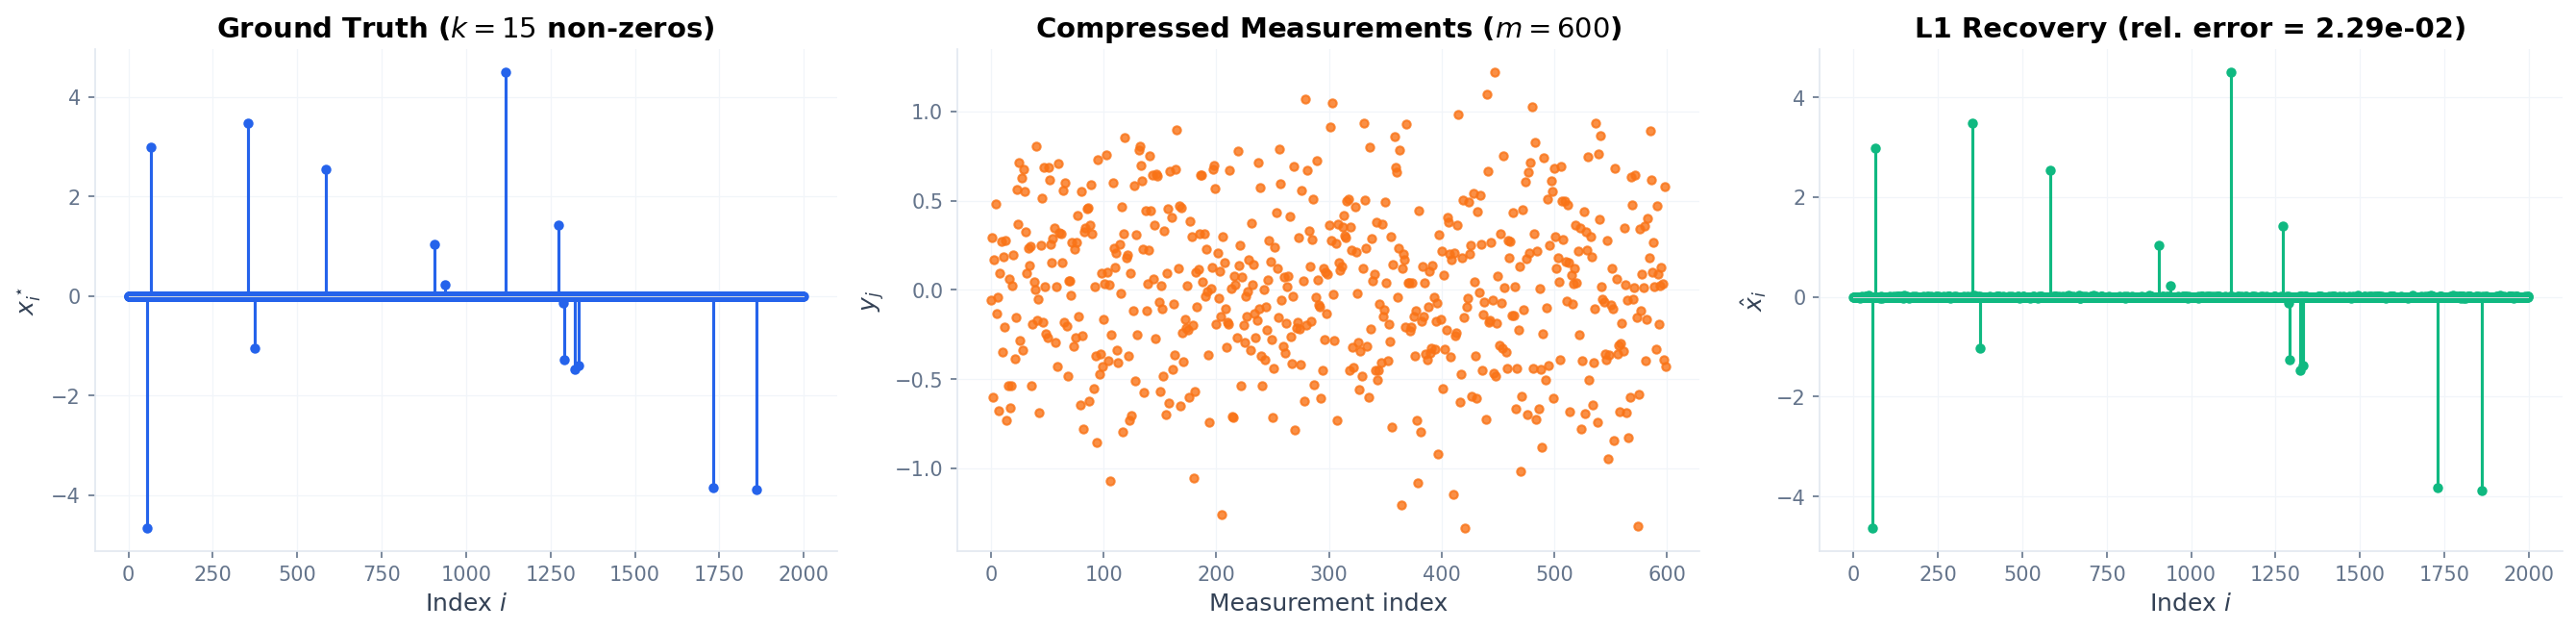

In [3]:
x = cp.Variable(n)
prob = cp.Problem(cp.Minimize(cp.norm1(x)), [Phi @ x == y])
prob.solve(solver=cp.MOREAU)

x_recovered = x.value

print(f"Status: {prob.status}")
print(f"||x_true||_1 = {np.abs(x_true).sum():.4f}")
print(f"||x_recovered||_1 = {np.abs(x_recovered).sum():.4f}")
print(f"Recovery error: ||x_recovered - x_true||_2 / ||x_true||_2 = {np.linalg.norm(x_recovered - x_true) / np.linalg.norm(x_true):.4e}")

# --- Triptych: ground truth / measurements / recovery ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Panel 1: Ground truth
ax = axes[0]
markerline, stemlines, baseline = ax.stem(np.arange(n), x_true, linefmt='-', markerfmt='o', basefmt='k-')
plt.setp(stemlines, color=MOREAU_COLORS['primary'], linewidth=1.5)
plt.setp(markerline, color=MOREAU_COLORS['primary'], markersize=4)
plt.setp(baseline, linewidth=0.5, color=MOREAU_COLORS['neutral_light'])
ax.set_xlabel('Index $i$')
ax.set_ylabel('$x^\\star_i$')
ax.set_title(f'Ground Truth ($k={k}$ non-zeros)')

# Panel 2: Measurements
ax = axes[1]
ax.plot(np.arange(m_meas), y, 'o', color=MOREAU_COLORS['accent'], markersize=4, alpha=0.8)
ax.set_xlabel('Measurement index')
ax.set_ylabel('$y_j$')
ax.set_title(f'Compressed Measurements ($m={m_meas}$)')

# Panel 3: Recovered signal
ax = axes[2]
markerline, stemlines, baseline = ax.stem(np.arange(n), x_recovered, linefmt='-', markerfmt='o', basefmt='k-')
plt.setp(stemlines, color=MOREAU_COLORS['success'], linewidth=1.5)
plt.setp(markerline, color=MOREAU_COLORS['success'], markersize=4)
plt.setp(baseline, linewidth=0.5, color=MOREAU_COLORS['neutral_light'])
ax.set_xlabel('Index $i$')
ax.set_ylabel('$\\hat{x}_i$')
rel_err = np.linalg.norm(x_recovered - x_true) / np.linalg.norm(x_true)
ax.set_title(f'L1 Recovery (rel. error = {rel_err:.2e})')

plt.tight_layout()
plt.show()

## Part B: 2D Image Reconstruction (Single-Pixel Camera)

A **single-pixel camera** captures an image by taking $m$ random linear projections of the scene — far fewer than the number of pixels $n = H \times W$. If the image is piecewise-smooth, we can reconstruct it by minimizing **total variation**:

$$\min_{x} \; \mathrm{TV}(x) \quad \text{s.t.} \quad \Phi \, x = y$$

where $\Phi \in \mathbb{R}^{m \times n}$ is the random measurement matrix and $y = \Phi \, x^\star + \eta$ are noisy compressed observations.

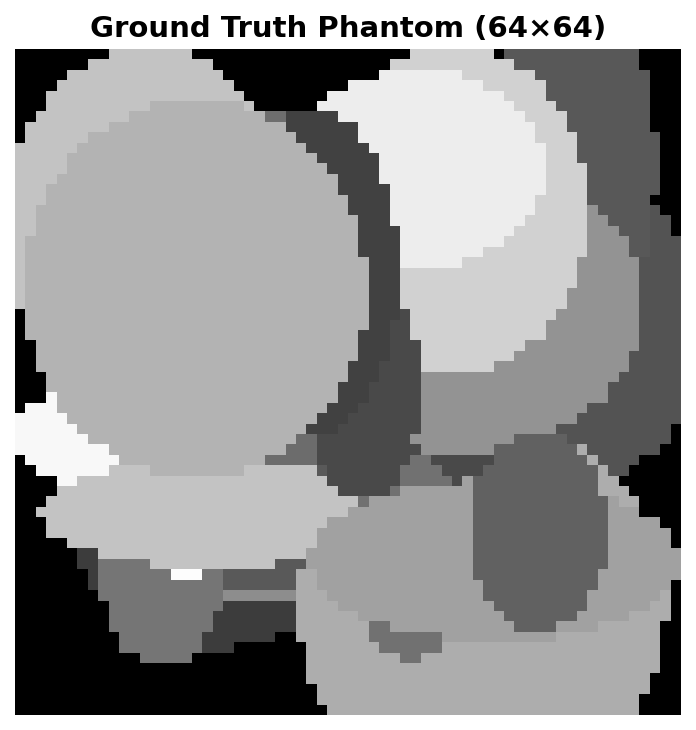

Image size: 64×64 = 4096 pixels
Pixel range: [0.00, 0.99]


In [4]:
def make_phantom(H, W, n_ellipses=25, seed=0):
    """Generate a phantom image with overlapping filled ellipses."""
    rng = np.random.RandomState(seed)
    img = np.zeros((H, W), dtype=np.float64)
    yy, xx = np.mgrid[:H, :W].astype(np.float64)

    for _ in range(n_ellipses):
        cy, cx = rng.uniform(0.15, 0.85, size=2) * [H, W]
        ry, rx = rng.uniform(0.08, 0.30, size=2) * [H, W]
        intensity = rng.uniform(0.2, 1.0)
        mask = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
        img[mask] = intensity

    return img

H, W = 64, 64
n_pixels = H * W
phantom = make_phantom(H, W, seed=42)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(phantom, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'Ground Truth Phantom ({H}×{W})')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image size: {H}×{W} = {n_pixels} pixels")
print(f"Pixel range: [{phantom.min():.2f}, {phantom.max():.2f}]")

### Total Variation Minimization

The 2D **anisotropic total variation** decomposes into horizontal and vertical finite differences:

$$\mathrm{TV}(x) = \|D_h x\|_1 + \|D_v x\|_1$$

where $D_h$ and $D_v$ are the horizontal and vertical difference operators. We build these as sparse matrices and let CVXPY + Moreau handle the LP reformulation automatically.

Status: optimal
PSNR: 44.8 dB


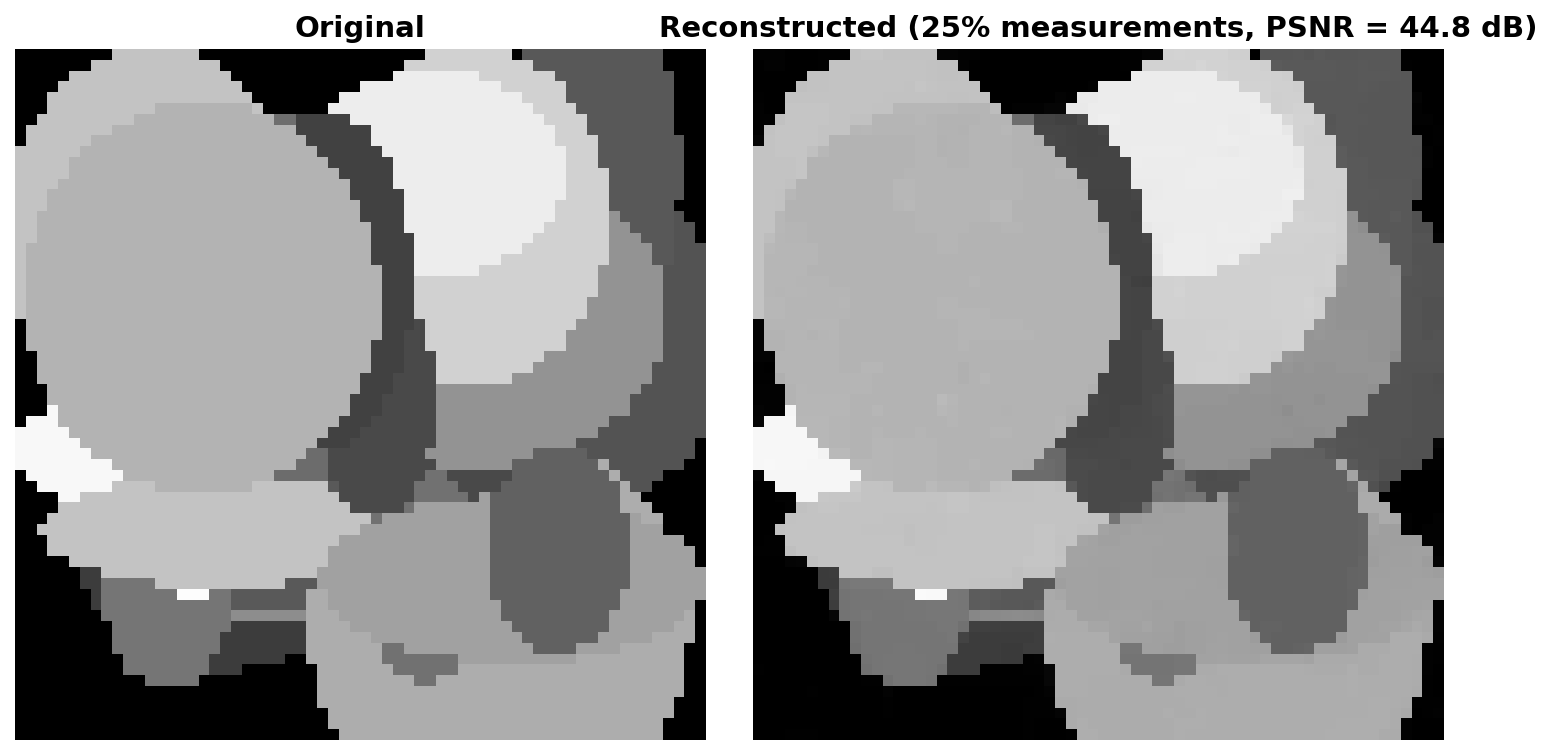

In [5]:
def build_diff_operators(H, W):
    """Build horizontal and vertical finite-difference operators for an H×W image."""
    n_pixels = H * W
    # D_h: horizontal differences, shape (H*(W-1), H*W)
    n_h = H * (W - 1)
    rows_h = np.arange(n_h)
    i_h = rows_h // (W - 1)
    j_h = rows_h % (W - 1)
    col_left = i_h * W + j_h
    col_right = col_left + 1
    D_h = sparse.csr_array(
        (np.concatenate([-np.ones(n_h), np.ones(n_h)]),
         (np.concatenate([rows_h, rows_h]), np.concatenate([col_left, col_right]))),
        shape=(n_h, n_pixels), dtype=np.float64,
    )
    # D_v: vertical differences, shape ((H-1)*W, H*W)
    n_v = (H - 1) * W
    rows_v = np.arange(n_v)
    col_top = (rows_v // W) * W + rows_v % W
    col_bot = col_top + W
    D_v = sparse.csr_array(
        (np.concatenate([-np.ones(n_v), np.ones(n_v)]),
         (np.concatenate([rows_v, rows_v]), np.concatenate([col_top, col_bot]))),
        shape=(n_v, n_pixels), dtype=np.float64,
    )
    return D_h, D_v


D_h, D_v = build_diff_operators(H, W)

# --- Solve at 25% compression ---
compression = 0.25
m_img = int(compression * n_pixels)
noise_std_img = 0.005

rng_phi = np.random.RandomState(123)
Phi_img = rng_phi.randn(m_img, n_pixels).astype(np.float64) / np.sqrt(m_img)
y_img = Phi_img @ phantom.ravel() + noise_std_img * np.random.RandomState(999).randn(m_img)

x_img = cp.Variable(n_pixels)
tv = cp.norm1(D_h @ x_img) + cp.norm1(D_v @ x_img)
prob_img = cp.Problem(cp.Minimize(tv), [Phi_img @ x_img == y_img])
prob_img.solve(solver=cp.MOREAU)

x_rec = x_img.value.reshape(H, W)
mse_img = np.mean((x_rec - phantom) ** 2)
psnr_img = 10 * np.log10(1.0 / mse_img) if mse_img > 0 else float('inf')

print(f"Status: {prob_img.status}")
print(f"PSNR: {psnr_img:.1f} dB")

# --- Side-by-side: original vs reconstructed ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(phantom, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(x_rec, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Reconstructed ({compression:.0%} measurements, PSNR = {psnr_img:.1f} dB)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Compression Ratio Sweep

How many measurements do we actually need? We vary the compression ratio $m/n$ from 5% to 50%. Each ratio gives a different-sized LP (the measurement matrix $\Phi$ changes dimensions), so we solve them sequentially.

  ratio=5%, m=204, PSNR=16.9 dB, status=optimal


  ratio=10%, m=409, PSNR=19.8 dB, status=optimal


  ratio=15%, m=614, PSNR=26.6 dB, status=optimal


  ratio=20%, m=819, PSNR=38.3 dB, status=optimal


  ratio=30%, m=1228, PSNR=45.6 dB, status=optimal


  ratio=50%, m=2048, PSNR=45.3 dB, status=optimal


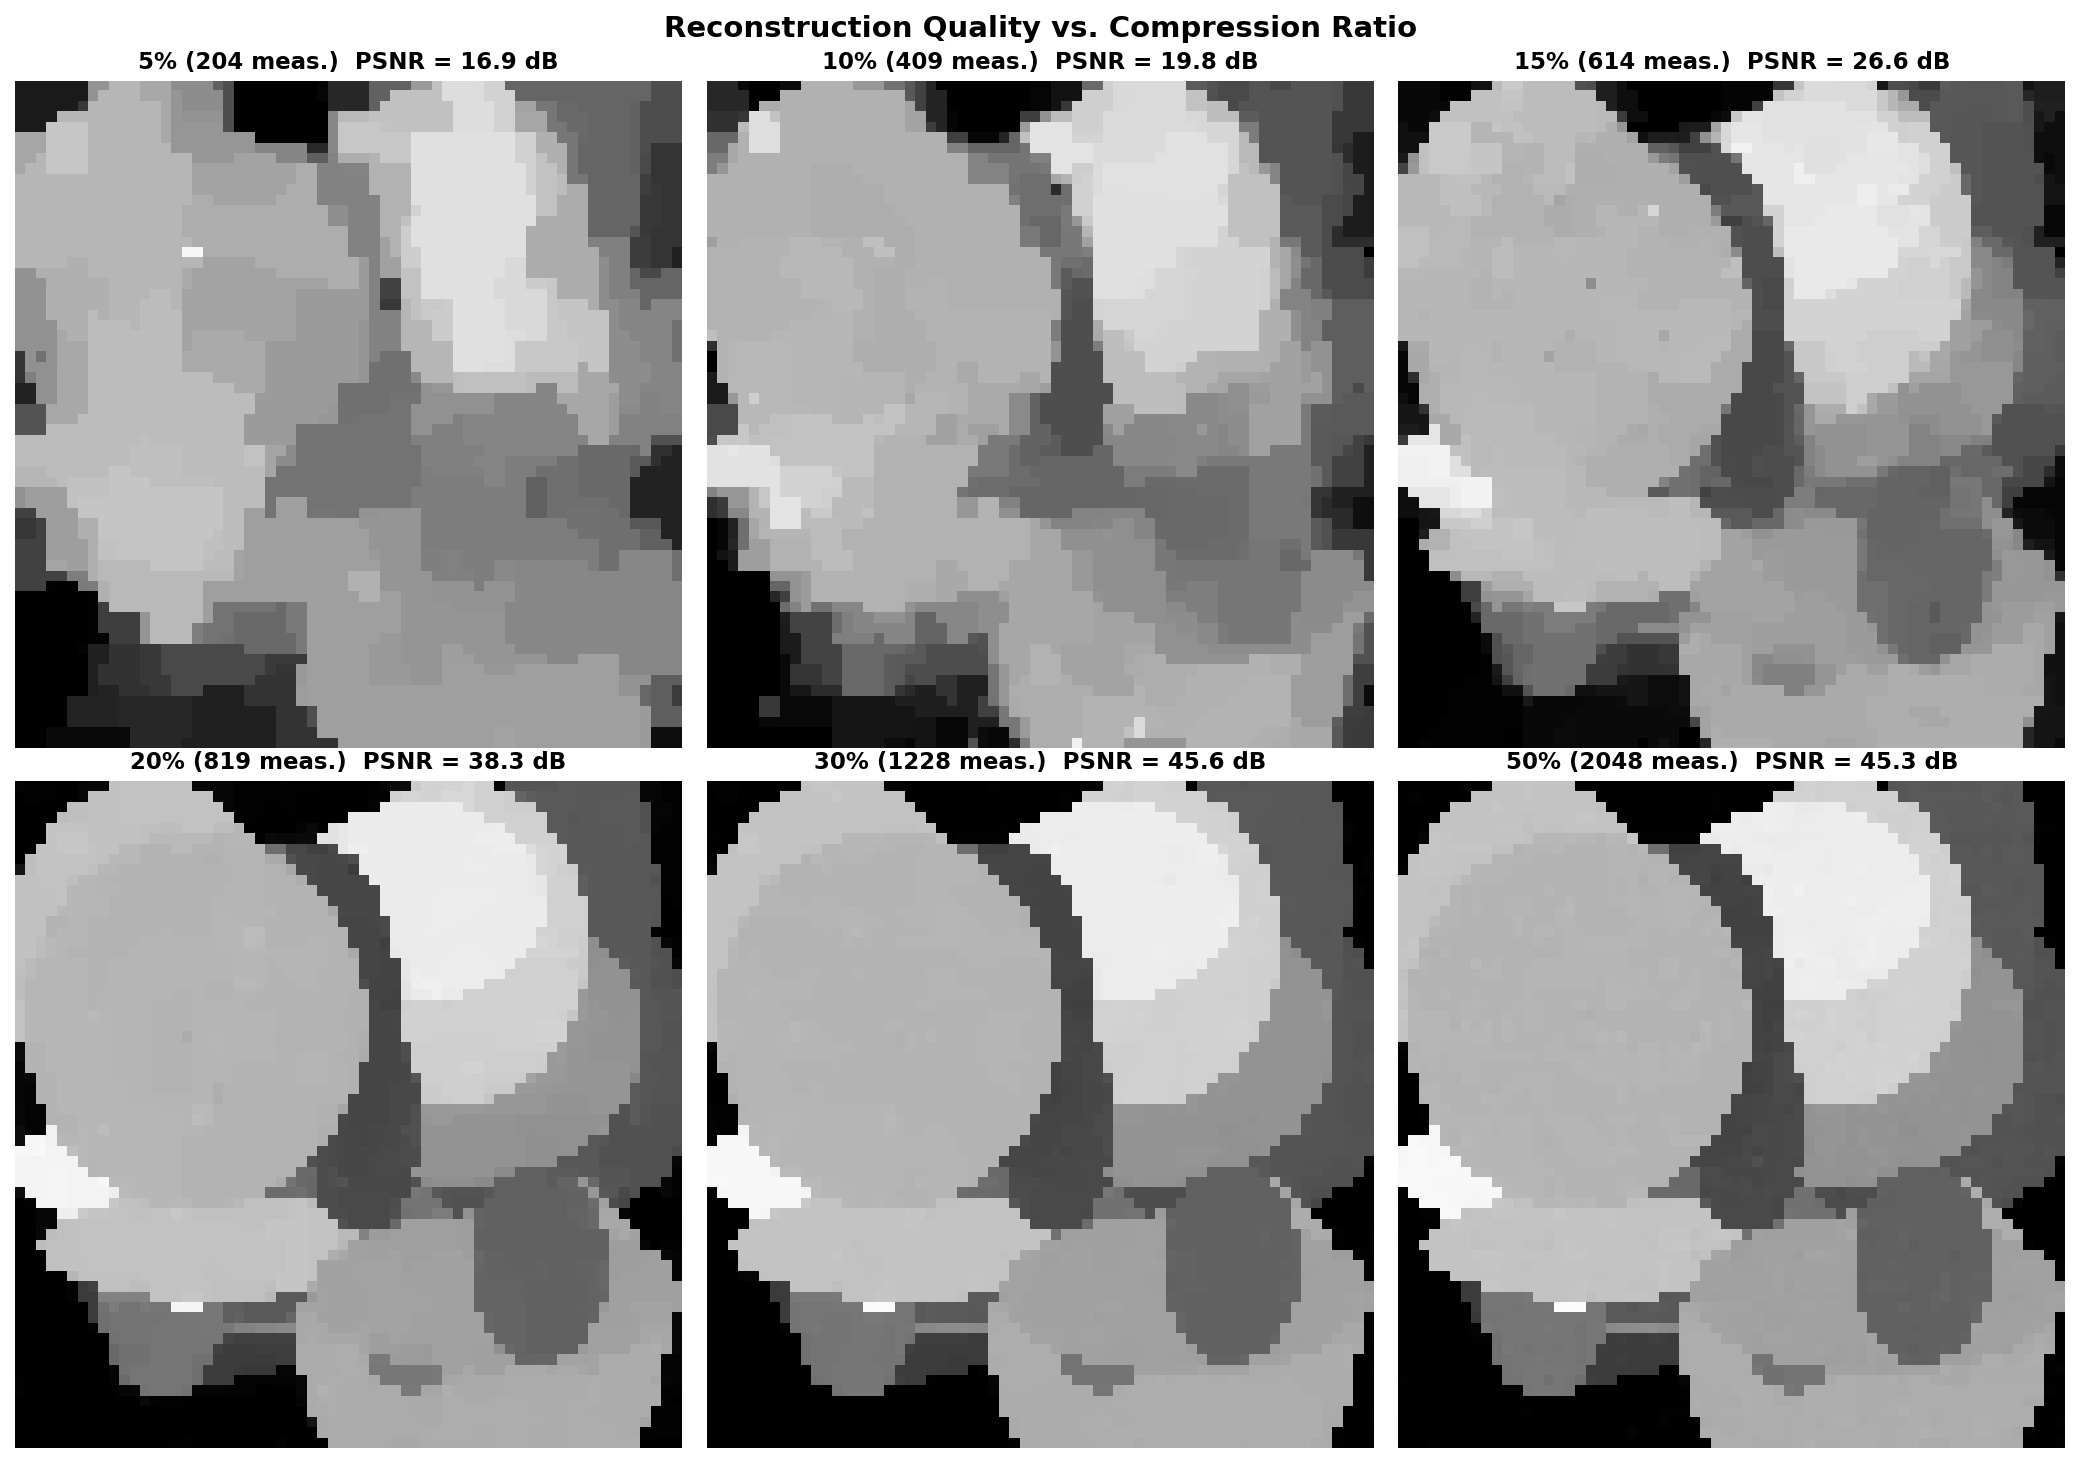

In [6]:
ratios = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
x_flat = phantom.ravel()
sweep_results = []

for ratio in ratios:
    m_sweep = int(ratio * n_pixels)
    rng_sweep = np.random.RandomState(123)
    Phi_sweep = rng_sweep.randn(m_sweep, n_pixels).astype(np.float64) / np.sqrt(m_sweep)
    y_sweep = Phi_sweep @ x_flat + noise_std_img * np.random.RandomState(999).randn(m_sweep)

    x_s = cp.Variable(n_pixels)
    tv_s = cp.norm1(D_h @ x_s) + cp.norm1(D_v @ x_s)
    prob_s = cp.Problem(cp.Minimize(tv_s), [Phi_sweep @ x_s == y_sweep])
    prob_s.solve(solver=cp.MOREAU)

    x_rec_s = x_s.value.reshape(H, W)
    mse_s = np.mean((x_rec_s - phantom) ** 2)
    psnr_s = 10 * np.log10(1.0 / mse_s) if mse_s > 0 else float('inf')
    sweep_results.append((ratio, m_sweep, x_rec_s, psnr_s))
    print(f"  ratio={ratio:.0%}, m={m_sweep}, PSNR={psnr_s:.1f} dB, status={prob_s.status}")

# --- 2×3 grid of reconstructions ---
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for idx, (ratio, m_sweep, x_s, psnr_s) in enumerate(sweep_results):
    ax = axes[idx // 3, idx % 3]
    ax.imshow(x_s, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{ratio:.0%} ({m_sweep} meas.)  PSNR = {psnr_s:.1f} dB', fontsize=11)
    ax.axis('off')

plt.suptitle('Reconstruction Quality vs. Compression Ratio', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../assets/compressed_sensing.png', bbox_inches='tight', facecolor='white')
plt.show()

---

**Key takeaways:**
- **1D compressed sensing** recovers a sparse signal from 30% of its measurements via L1 basis pursuit
- **2D image reconstruction** recovers a 64×64 phantom from random projections by minimizing total variation — the "single-pixel camera" problem
- Moreau's **CVXPY backend** (`solver=cp.MOREAU`) lets you formulate problems in CVXPY's modeling language while solving with Moreau under the hood
- At 20–25% compression, TV minimization achieves high-fidelity reconstruction; below 10%, artifacts dominate